# Modeling Notebook — PubMed RCT 20k

**Dataset:** `armanc/pubmed-rct20k`  
**Task:** 5-class sentence-level classification (BACKGROUND / OBJECTIVE / METHODS / RESULTS / CONCLUSIONS)

**Models implemented:**
1. **LSTM Baseline** — Embedding → BiLSTM → Dropout → Linear classifier
2. **Transformer Fine-tune** — `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract` (or `distilbert-base-uncased`)

**Metrics reported:**  
Accuracy · Macro F1 · Per-class Precision/Recall/F1 · Confusion Matrix · Perplexity · Training curves

## 0. Setup & Configuration

In [1]:
# !pip install datasets transformers torch scikit-learn matplotlib seaborn tqdm

import os
import math
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

WORK_DIR = Path('.')
FIG_DIR = WORK_DIR / 'figures'
LOG_DIR = WORK_DIR / 'logs'
MODEL_DIR = WORK_DIR / 'models'
for d in [FIG_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters (edit here) ──────────────────────────────────────────────
CFG = dict(
    # Data
    max_length     = 128,      # max tokens per sentence
    # LSTM
    vocab_min_freq = 2,        # min word frequency for LSTM vocab
    embed_dim      = 128,
    hidden_dim     = 256,
    n_lstm_layers  = 2,
    lstm_dropout   = 0.3,
    lstm_lr        = 1e-3,
    lstm_epochs    = 100,
    lstm_batch     = 128,
    # Transformer
    model_name     = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract',
    # Fallback if above is slow to download:
    # model_name   = 'distilbert-base-uncased',
    transf_lr      = 2e-5,
    transf_epochs  = 3,
    transf_batch   = 32,
    warmup_ratio   = 0.1,
    weight_decay   = 0.01,
    # Shared
    num_labels     = 5,
)

LABEL_ORDER = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
label2int = {label: idx for idx, label in enumerate(LABEL_ORDER)}
int2label = {idx: label for label, idx in label2int.items()}
print('Config loaded.')

/blue/bme6938/share/conda/pt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Config loaded.


## 1. Load & Prepare Data

In [2]:
ds = load_dataset('armanc/pubmed-rct20k')
print(ds)

print('Dataset label column type:', type(ds['train'][0]['label']).__name__)
print('Label map:', int2label)

train_texts  = ds['train']['text']
train_labels = [label2int[label.upper()] for label in ds['train']['label']]
val_texts    = ds['validation']['text']
val_labels   = [label2int[label.upper()] for label in ds['validation']['label']]
test_texts   = ds['test']['text']
test_labels  = [label2int[label.upper()] for label in ds['test']['label']]

print(f'Train: {len(train_texts):,} | Val: {len(val_texts):,} | Test: {len(test_texts):,}')

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})
Dataset label column type: str
Label map: {0: 'BACKGROUND', 1: 'OBJECTIVE', 2: 'METHODS', 3: 'RESULTS', 4: 'CONCLUSIONS'}
Train: 176,642 | Val: 29,672 | Test: 29,578


In [3]:
# ── Compute class weights for imbalance handling ─────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CFG['num_labels']),
    y=np.array(train_labels)
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', {int2label[i]: f'{w:.3f}' for i, w in enumerate(class_weights)})

Class weights: {'BACKGROUND': '1.920', 'OBJECTIVE': '2.553', 'METHODS': '0.596', 'RESULTS': '0.610', 'CONCLUSIONS': '1.300'}


## 2. LSTM Baseline
### 2.1 Vocabulary & Tokenization

In [7]:
import re

def lstm_tokenize(text):
    """Simple whitespace + punctuation tokenizer for LSTM."""
    text = text.lower()
    text = re.sub(r'([.,!?;:\-/\(\)\[\]{}\"\'])', r' \1 ', text)
    return text.split()

# Build vocabulary from training set
counter = Counter(tok for sent in train_texts for tok in lstm_tokenize(sent))
vocab_words = [w for w, c in counter.items() if c >= CFG['vocab_min_freq']]

PAD_IDX = 0
UNK_IDX = 1
word2idx = {w: i + 2 for i, w in enumerate(vocab_words)}
vocab_size = len(word2idx) + 2  # +2 for PAD and UNK

print(f'Vocabulary size (min_freq={CFG["vocab_min_freq"]}): {vocab_size:,}')

def encode(text, max_len=CFG['max_length']):
    """Encode text to padded/truncated integer sequence."""
    ids = [word2idx.get(t, UNK_IDX) for t in lstm_tokenize(text)][:max_len]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

Vocabulary size (min_freq=2): 34,122


In [8]:
class SentenceDataset(TorchDataset):
    """PyTorch Dataset wrapping encoded text and labels."""
    def __init__(self, texts, labels, encoder_fn):
        self.x = [torch.tensor(encoder_fn(t), dtype=torch.long) for t in texts]
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

lstm_train_ds = SentenceDataset(train_texts, train_labels, encode)
lstm_val_ds   = SentenceDataset(val_texts,   val_labels,   encode)
lstm_test_ds  = SentenceDataset(test_texts,  test_labels,  encode)

lstm_train_loader = DataLoader(lstm_train_ds, batch_size=CFG['lstm_batch'], shuffle=True,  num_workers=2, pin_memory=True)
lstm_val_loader   = DataLoader(lstm_val_ds,   batch_size=CFG['lstm_batch'], shuffle=False, num_workers=2, pin_memory=True)
lstm_test_loader  = DataLoader(lstm_test_ds,  batch_size=CFG['lstm_batch'], shuffle=False, num_workers=2, pin_memory=True)
print('DataLoaders created.')

DataLoaders created.


### 2.2 BiLSTM Model Definition

In [9]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM text classifier.

    Architecture:
        Embedding → BiLSTM (n_layers) → mean pooling → Dropout → Linear

    Args:
        vocab_size (int): Vocabulary size including PAD and UNK tokens.
        embed_dim (int): Embedding dimension.
        hidden_dim (int): LSTM hidden state size (per direction).
        n_layers (int): Number of stacked LSTM layers.
        dropout (float): Dropout probability applied between layers and after pooling.
        num_classes (int): Number of output classes.
        pad_idx (int): Index of the padding token.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers,
                 dropout, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        """
        Args:
            x: LongTensor of shape (batch, seq_len)
        Returns:
            logits: FloatTensor of shape (batch, num_classes)
        """
        emb = self.dropout(self.embedding(x))        # (B, L, E)
        out, _ = self.lstm(emb)                      # (B, L, 2*H)
        # Mean pooling over non-padding positions
        mask = (x != PAD_IDX).unsqueeze(-1).float()  # (B, L, 1)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        logits = self.fc(self.dropout(pooled))       # (B, C)
        return logits


lstm_model = BiLSTMClassifier(
    vocab_size  = vocab_size,
    embed_dim   = CFG['embed_dim'],
    hidden_dim  = CFG['hidden_dim'],
    n_layers    = CFG['n_lstm_layers'],
    dropout     = CFG['lstm_dropout'],
    num_classes = CFG['num_labels'],
    pad_idx     = PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(lstm_model)
print(f'\nTrainable parameters: {total_params:,}')

# Notebook-safe data loading: avoid multiprocessing workers in Jupyter.
lstm_train_loader = DataLoader(
    lstm_train_ds,
    batch_size=CFG['lstm_batch'],
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
lstm_val_loader = DataLoader(
    lstm_val_ds,
    batch_size=CFG['lstm_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
lstm_test_loader = DataLoader(
    lstm_test_ds,
    batch_size=CFG['lstm_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

BiLSTMClassifier(
  (embedding): Embedding(34122, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=5, bias=True)
)

Trainable parameters: 6,737,669


### 2.3 Training Loop

In [10]:
def compute_perplexity(avg_cross_entropy_loss: float) -> float:
    """
    Compute perplexity from average cross-entropy loss.

    For classification, perplexity = exp(CE_loss).
    Interpretation: lower is better; perfect predictions → perplexity = 1.
    Random baseline for 5-class problem → perplexity ≈ 5.

    Args:
        avg_cross_entropy_loss: Mean cross-entropy loss over dataset.
    Returns:
        Perplexity value.
    """
    return math.exp(avg_cross_entropy_loss)


def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    """Run one training epoch. Returns (avg_loss, accuracy, perplexity)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(loader, desc='  Train', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate model. Returns (avg_loss, accuracy, perplexity, all_preds, all_labels)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for x, y in tqdm(loader, desc='  Eval ', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss), all_preds, all_labels


print('Training utilities defined.')

Training utilities defined.


In [11]:
lstm_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=CFG['lstm_lr'])
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    lstm_optimizer, mode='min', patience=2, factor=0.5
)

lstm_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                'train_ppl': [], 'val_ppl': []}
best_val_loss = float('inf')
LSTM_CKPT = MODEL_DIR / 'lstm_best.pt'

print(f'Training BiLSTM for {CFG["lstm_epochs"]} epochs...\n')

for epoch in range(1, CFG['lstm_epochs'] + 1):
    tr_loss, tr_acc, tr_ppl = train_epoch(lstm_model, lstm_train_loader, lstm_optimizer, lstm_criterion)
    vl_loss, vl_acc, vl_ppl, _, _ = evaluate(lstm_model, lstm_val_loader, lstm_criterion)

    lstm_scheduler.step(vl_loss)

    lstm_history['train_loss'].append(tr_loss)
    lstm_history['val_loss'].append(vl_loss)
    lstm_history['train_acc'].append(tr_acc)
    lstm_history['val_acc'].append(vl_acc)
    lstm_history['train_ppl'].append(tr_ppl)
    lstm_history['val_ppl'].append(vl_ppl)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(lstm_model.state_dict(), LSTM_CKPT)

    print(f'Epoch {epoch:02d}/{CFG["lstm_epochs"]} | '
          f'Train Loss: {tr_loss:.4f} (PPL {tr_ppl:.2f}) Acc {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} (PPL {vl_ppl:.2f}) Acc {vl_acc:.4f}')

print(f'\nBest val loss: {best_val_loss:.4f} → checkpoint saved to {LSTM_CKPT}')

Training BiLSTM for 100 epochs...



Epoch 01/100 | Train Loss: 0.7635 (PPL 2.15) Acc 0.7469 | Val Loss: 0.6022 (PPL 1.83) Acc 0.8219


Epoch 02/100 | Train Loss: 0.6012 (PPL 1.82) Acc 0.8144 | Val Loss: 0.5568 (PPL 1.75) Acc 0.8365


Epoch 03/100 | Train Loss: 0.5466 (PPL 1.73) Acc 0.8338 | Val Loss: 0.5434 (PPL 1.72) Acc 0.8386


Epoch 04/100 | Train Loss: 0.5087 (PPL 1.66) Acc 0.8454 | Val Loss: 0.5413 (PPL 1.72) Acc 0.8408


...

Epoch 96/100 | Train Loss: 0.1742 (PPL 1.19) Acc 0.9399 | Val Loss: 0.9198 (PPL 2.51) Acc 0.8406


Epoch 97/100 | Train Loss: 0.1731 (PPL 1.19) Acc 0.9401 | Val Loss: 0.9198 (PPL 2.51) Acc 0.8406


Epoch 98/100 | Train Loss: 0.1741 (PPL 1.19) Acc 0.9392 | Val Loss: 0.9198 (PPL 2.51) Acc 0.8406


Epoch 99/100 | Train Loss: 0.1731 (PPL 1.19) Acc 0.9396 | Val Loss: 0.9198 (PPL 2.51) Acc 0.8406


Epoch 100/100 | Train Loss: 0.1759 (PPL 1.19) Acc 0.9391 | Val Loss: 0.9198 (PPL 2.51) Acc 0.8406

Best val loss: 0.5358 → checkpoint saved to models/lstm_best.pt


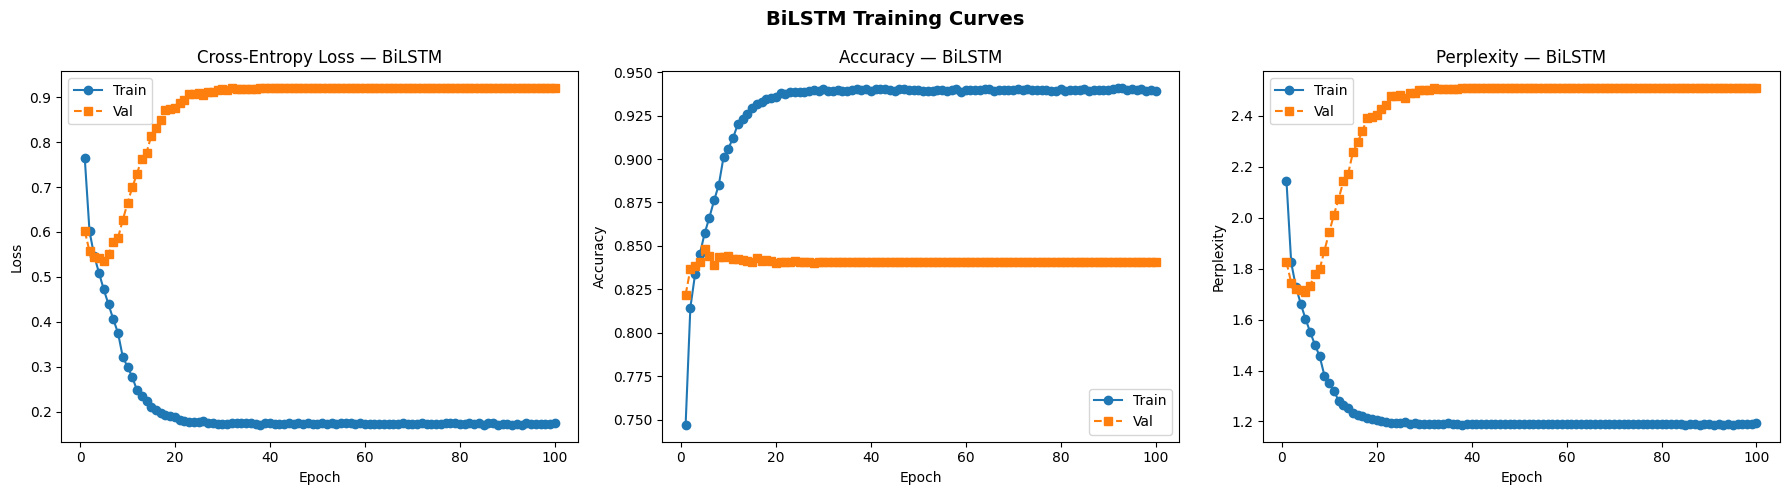

Saved: lstm_training_curves.png


In [12]:
# ── Plot LSTM training curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = range(1, CFG['lstm_epochs'] + 1)

ax = axes[0]
ax.plot(epochs_x, lstm_history['train_loss'], 'o-', label='Train')
ax.plot(epochs_x, lstm_history['val_loss'],   's--', label='Val')
ax.set_title('Cross-Entropy Loss — BiLSTM'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()

ax = axes[1]
ax.plot(epochs_x, lstm_history['train_acc'], 'o-', label='Train')
ax.plot(epochs_x, lstm_history['val_acc'],   's--', label='Val')
ax.set_title('Accuracy — BiLSTM'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend()

ax = axes[2]
ax.plot(epochs_x, lstm_history['train_ppl'], 'o-', label='Train')
ax.plot(epochs_x, lstm_history['val_ppl'],   's--', label='Val')
ax.set_title('Perplexity — BiLSTM'); ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity'); ax.legend()

plt.suptitle('BiLSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lstm_training_curves.png')

### 2.4 LSTM Test Evaluation

In [13]:
# Load best checkpoint
lstm_model.load_state_dict(torch.load(LSTM_CKPT, map_location=DEVICE))

test_loss, test_acc, test_ppl, lstm_preds, lstm_true = evaluate(
    lstm_model, lstm_test_loader, lstm_criterion
)

lstm_macro_f1  = f1_score(lstm_true, lstm_preds, average='macro')
lstm_weighted_f1 = f1_score(lstm_true, lstm_preds, average='weighted')

print('=== BiLSTM — Test Set Results ===')
print(f'  Loss:        {test_loss:.4f}')
print(f'  Perplexity:  {test_ppl:.4f}')
print(f'  Accuracy:    {test_acc:.4f}')
print(f'  Macro F1:    {lstm_macro_f1:.4f}')
print(f'  Weighted F1: {lstm_weighted_f1:.4f}')
print()
print(classification_report(lstm_true, lstm_preds, target_names=LABEL_ORDER, digits=4))

  Eval :   0%|          | 0/232 [00:00<?, ?it/s]

=== BiLSTM — Test Set Results ===
  Loss:        0.5661
  Perplexity:  1.7614
  Accuracy:    0.8395
  Macro F1:    0.7758
  Weighted F1: 0.8397

              precision    recall  f1-score   support

  BACKGROUND     0.6073    0.6896    0.6459      3077
   OBJECTIVE     0.7025    0.5739    0.6318      2333
     METHODS     0.9092    0.9274    0.9182      9884
     RESULTS     0.9147    0.8770    0.8955      9713
 CONCLUSIONS     0.7703    0.8064    0.7879      4571

    accuracy                         0.8395     29578
   macro avg     0.7808    0.7749    0.7758     29578
weighted avg     0.8419    0.8395    0.8397     29578



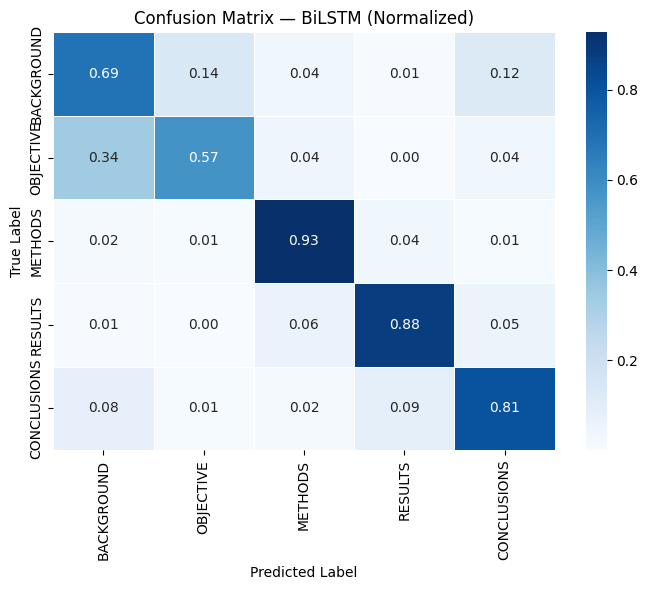

Saved: figures/lstm_confusion_matrix.png


In [14]:
def plot_confusion_matrix(y_true, y_pred, label_names, title, save_path):
    """Plot and save a normalized confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_confusion_matrix(lstm_true, lstm_preds, LABEL_ORDER,
                      'Confusion Matrix — BiLSTM (Normalized)', FIG_DIR / 'lstm_confusion_matrix.png')

## 3. Transformer Fine-tuning (PubMedBERT / DistilBERT)
### 3.1 Tokenization & Dataset

In [4]:
transf_tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print(f'Loaded tokenizer: {CFG["model_name"]}')
print(f'Vocab size: {transf_tokenizer.vocab_size:,}')

# Quick sanity check
sample_enc = transf_tokenizer(
    'Patients were randomized to receive treatment.',
    max_length=CFG['max_length'], padding='max_length', truncation=True
)
print('Sample input_ids:', sample_enc['input_ids'][:10], '...')

Loaded tokenizer: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Vocab size: 28,895
Sample input_ids: [2, 1808, 1748, 4384, 1701, 6696, 2015, 17, 3, 0] ...


In [5]:
class TransformerDataset(TorchDataset):
    """
    HuggingFace tokenizer-based dataset for sequence classification.

    Args:
        texts: List of raw text strings.
        labels: List of integer labels.
        tokenizer: HuggingFace tokenizer instance.
        max_length: Maximum sequence length (padding + truncation).
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        # Tokenize on-the-fly to avoid loading all 235k samples into memory
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {k: v[0] for k, v in encoding.items()}  # Remove batch dimension added by return_tensors
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item


transf_train_ds = TransformerDataset(train_texts, train_labels, transf_tokenizer, CFG['max_length'])
transf_val_ds   = TransformerDataset(val_texts,   val_labels,   transf_tokenizer, CFG['max_length'])
transf_test_ds  = TransformerDataset(test_texts,  test_labels,  transf_tokenizer, CFG['max_length'])

# Notebook-safe data loading: avoid multiprocessing workers in Jupyter.
transf_train_loader = DataLoader(
    transf_train_ds,
    batch_size=CFG['transf_batch'],
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
transf_val_loader = DataLoader(
    transf_val_ds,
    batch_size=CFG['transf_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
transf_test_loader = DataLoader(
    transf_test_ds,
    batch_size=CFG['transf_batch'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
print(f'Dataset sizes — Train: {len(transf_train_ds):,} | Val: {len(transf_val_ds):,} | Test: {len(transf_test_ds):,}')

Dataset sizes — Train: 176,642 | Val: 29,672 | Test: 29,578


### 3.2 Load Pretrained Model

In [6]:
transf_model = AutoModelForSequenceClassification.from_pretrained(
    CFG['model_name'],
    num_labels=CFG['num_labels'],
    ignore_mismatched_sizes=True
).to(DEVICE)

total_params = sum(p.numel() for p in transf_model.parameters())
trainable    = sum(p.numel() for p in transf_model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,} | Trainable: {trainable:,}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 70531.22it/s]
BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from differe

Total params: 109,486,085 | Trainable: 109,486,085


### 3.3 Fine-tuning Loop

In [15]:
# Optimizer with weight decay (no decay on bias/LayerNorm)
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in transf_model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': CFG['weight_decay']},
    {'params': [p for n, p in transf_model.named_parameters() if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
transf_optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=CFG['transf_lr'])

total_steps   = len(transf_train_loader) * CFG['transf_epochs']
warmup_steps  = int(total_steps * CFG['warmup_ratio'])
transf_scheduler = get_linear_schedule_with_warmup(
    transf_optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

transf_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f'Total steps: {total_steps:,} | Warmup steps: {warmup_steps:,}')

Total steps: 16,563 | Warmup steps: 1,656


In [16]:
def train_epoch_transf(model, loader, optimizer, scheduler, criterion):
    """One fine-tuning epoch for a HuggingFace sequence classifier."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in tqdm(loader, desc='  Train', leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        logits = outputs.logits
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss)


@torch.no_grad()
def evaluate_transf(model, loader, criterion):
    """Evaluate a HuggingFace sequence classifier."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  Eval ', leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        logits = outputs.logits
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    return avg_loss, correct / total, compute_perplexity(avg_loss), all_preds, all_labels


print('Transformer training utilities defined.')

Transformer training utilities defined.


In [17]:
transf_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                  'train_ppl': [], 'val_ppl': []}
best_val_loss_transf = float('inf')
TRANSF_CKPT = MODEL_DIR / 'transf_best.pt'

print(f'Fine-tuning {CFG["model_name"]} for {CFG["transf_epochs"]} epochs...\n')

for epoch in range(1, CFG['transf_epochs'] + 1):
    tr_loss, tr_acc, tr_ppl = train_epoch_transf(
        transf_model, transf_train_loader, transf_optimizer, transf_scheduler, transf_criterion
    )
    vl_loss, vl_acc, vl_ppl, _, _ = evaluate_transf(
        transf_model, transf_val_loader, transf_criterion
    )

    transf_history['train_loss'].append(tr_loss)
    transf_history['val_loss'].append(vl_loss)
    transf_history['train_acc'].append(tr_acc)
    transf_history['val_acc'].append(vl_acc)
    transf_history['train_ppl'].append(tr_ppl)
    transf_history['val_ppl'].append(vl_ppl)

    if vl_loss < best_val_loss_transf:
        best_val_loss_transf = vl_loss
        torch.save(transf_model.state_dict(), TRANSF_CKPT)

    print(f'Epoch {epoch:02d}/{CFG["transf_epochs"]} | '
          f'Train Loss: {tr_loss:.4f} (PPL {tr_ppl:.2f}) Acc {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} (PPL {vl_ppl:.2f}) Acc {vl_acc:.4f}')

print(f'\nBest val loss: {best_val_loss_transf:.4f} → checkpoint saved to {TRANSF_CKPT}')

Fine-tuning microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract for 3 epochs...



Epoch 01/3 | Train Loss: 0.5334 (PPL 1.70) Acc 0.8440 | Val Loss: 0.4219 (PPL 1.52) Acc 0.8761


Epoch 02/3 | Train Loss: 0.3899 (PPL 1.48) Acc 0.8920 | Val Loss: 0.4236 (PPL 1.53) Acc 0.8816


Epoch 03/3 | Train Loss: 0.3032 (PPL 1.35) Acc 0.9180 | Val Loss: 0.4516 (PPL 1.57) Acc 0.8822

Best val loss: 0.4219 → checkpoint saved to models/transf_best.pt


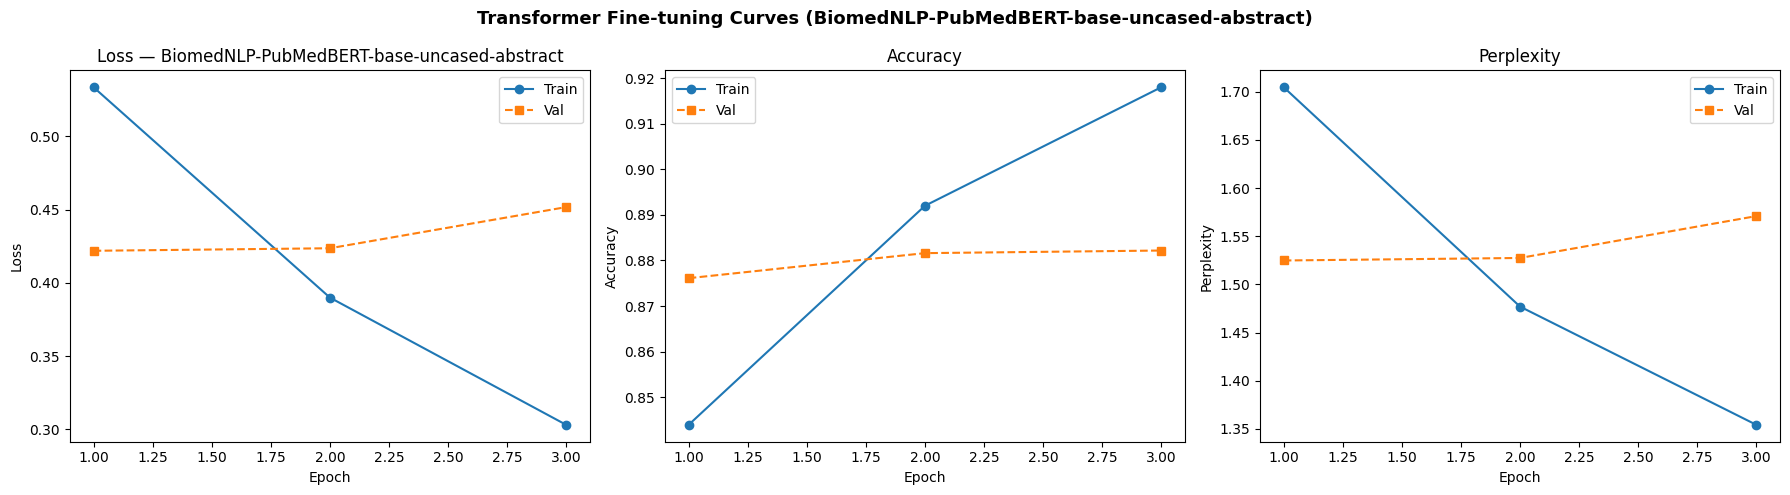

Saved: transf_training_curves.png


In [18]:
# ── Transformer training curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = range(1, CFG['transf_epochs'] + 1)

ax = axes[0]
ax.plot(epochs_x, transf_history['train_loss'], 'o-', label='Train')
ax.plot(epochs_x, transf_history['val_loss'],   's--', label='Val')
ax.set_title(f'Loss — {CFG["model_name"].split("/")[-1]}'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()

ax = axes[1]
ax.plot(epochs_x, transf_history['train_acc'], 'o-', label='Train')
ax.plot(epochs_x, transf_history['val_acc'],   's--', label='Val')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend()

ax = axes[2]
ax.plot(epochs_x, transf_history['train_ppl'], 'o-', label='Train')
ax.plot(epochs_x, transf_history['val_ppl'],   's--', label='Val')
ax.set_title('Perplexity'); ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity'); ax.legend()

plt.suptitle(f'Transformer Fine-tuning Curves ({CFG["model_name"].split("/")[-1]})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'transf_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: transf_training_curves.png')

### 3.4 Transformer Test Evaluation

In [19]:
transf_model.load_state_dict(torch.load(TRANSF_CKPT, map_location=DEVICE))

tt_loss, tt_acc, tt_ppl, transf_preds, transf_true = evaluate_transf(
    transf_model, transf_test_loader, transf_criterion
)

transf_macro_f1    = f1_score(transf_true, transf_preds, average='macro')
transf_weighted_f1 = f1_score(transf_true, transf_preds, average='weighted')

print(f'=== {CFG["model_name"].split("/")[-1]} — Test Set Results ===')
print(f'  Loss:        {tt_loss:.4f}')
print(f'  Perplexity:  {tt_ppl:.4f}')
print(f'  Accuracy:    {tt_acc:.4f}')
print(f'  Macro F1:    {transf_macro_f1:.4f}')
print(f'  Weighted F1: {transf_weighted_f1:.4f}')
print()
print(classification_report(transf_true, transf_preds, target_names=LABEL_ORDER, digits=4))

=== BiomedNLP-PubMedBERT-base-uncased-abstract — Test Set Results ===
  Loss:        0.4481
  Perplexity:  1.5653
  Accuracy:    0.8664
  Macro F1:    0.8085
  Weighted F1: 0.8677

              precision    recall  f1-score   support

  BACKGROUND     0.6560    0.7394    0.6952      3077
   OBJECTIVE     0.6690    0.6429    0.6557      2333
     METHODS     0.9373    0.9464    0.9418      9884
     RESULTS     0.9466    0.8803    0.9122      9713
 CONCLUSIONS     0.8128    0.8635    0.8374      4571

    accuracy                         0.8664     29578
   macro avg     0.8044    0.8145    0.8085     29578
weighted avg     0.8707    0.8664    0.8677     29578



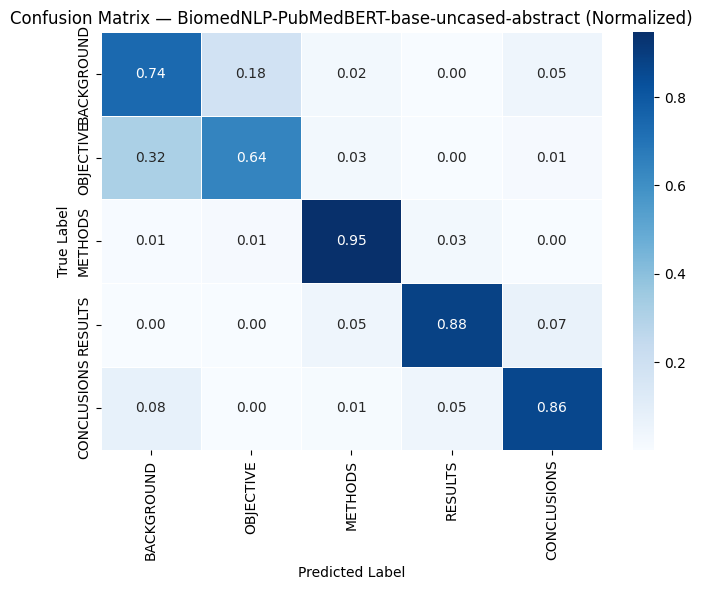

Saved: figures/transf_confusion_matrix.png


In [20]:
plot_confusion_matrix(transf_true, transf_preds, LABEL_ORDER,
                      f'Confusion Matrix — {CFG["model_name"].split("/")[-1]} (Normalized)',
                      FIG_DIR / 'transf_confusion_matrix.png')

## 4. Model Comparison

In [21]:
# ── Summary comparison table ─────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

def model_summary(name, preds, true, loss, ppl):
    return {
        'Model'       : name,
        'Test Loss'   : round(loss, 4),
        'Perplexity'  : round(ppl, 4),
        'Accuracy'    : round(accuracy_score(true, preds), 4),
        'Macro F1'    : round(f1_score(true, preds, average='macro'), 4),
        'Macro Prec.' : round(precision_score(true, preds, average='macro'), 4),
        'Macro Rec.'  : round(recall_score(true, preds, average='macro'), 4),
        'Weighted F1' : round(f1_score(true, preds, average='weighted'), 4),
    }

results_df = pd.DataFrame([
    model_summary('BiLSTM (baseline)', lstm_preds, lstm_true, test_loss, test_ppl),
    model_summary(CFG['model_name'].split('/')[-1], transf_preds, transf_true, tt_loss, tt_ppl),
])
results_df = results_df.set_index('Model')
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string())


=== MODEL COMPARISON ===
                                            Test Loss  Perplexity  Accuracy  Macro F1  Macro Prec.  Macro Rec.  Weighted F1
Model                                                                                                                      
BiLSTM (baseline)                              0.5661      1.7614    0.8395    0.7758       0.7808      0.7749       0.8397
BiomedNLP-PubMedBERT-base-uncased-abstract     0.4481      1.5653    0.8664    0.8085       0.8044      0.8145       0.8677


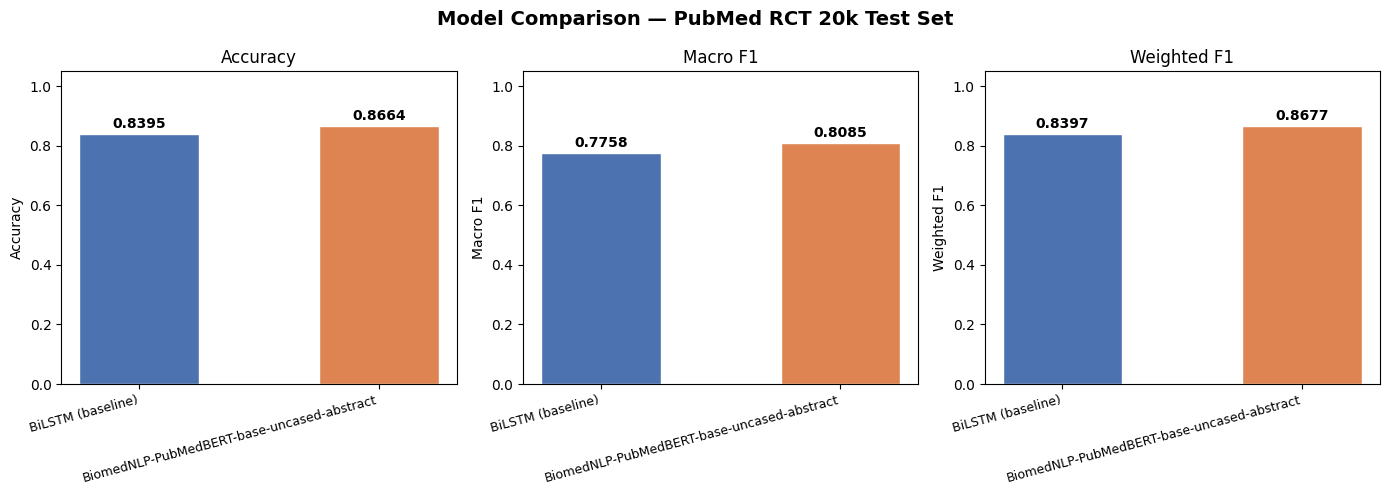

Saved: model_comparison.png


In [22]:
# ── Bar chart comparison ─────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Macro F1', 'Weighted F1']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df[metric].values
    models = results_df.index.tolist()
    bars = ax.bar(models, vals, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison — PubMed RCT 20k Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

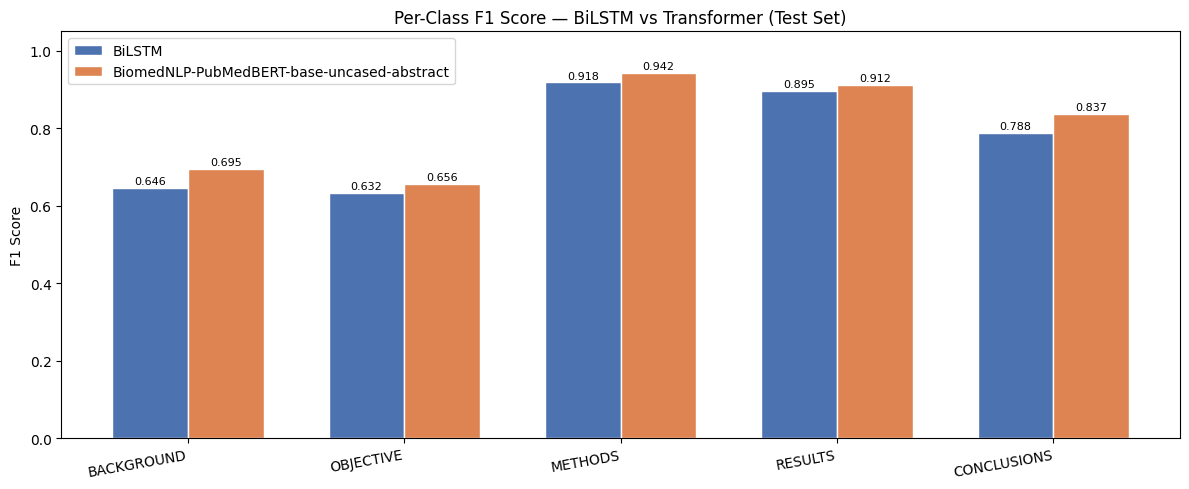

Saved: per_class_f1.png


In [23]:
# ── Per-class F1 comparison ──────────────────────────────────────────────────
lstm_per_class    = f1_score(lstm_true,   lstm_preds,   average=None, labels=list(range(5)))
transf_per_class  = f1_score(transf_true, transf_preds, average=None, labels=list(range(5)))

x = np.arange(len(LABEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, lstm_per_class,   width, label='BiLSTM',     color='#4C72B0', edgecolor='white')
ax.bar(x + width/2, transf_per_class, width, label=CFG['model_name'].split('/')[-1],
       color='#DD8452', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER, rotation=10, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 Score — BiLSTM vs Transformer (Test Set)')
ax.legend()
for xi, (v1, v2) in zip(x, zip(lstm_per_class, transf_per_class)):
    ax.text(xi - width/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=8)
    ax.text(xi + width/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_f1.png')

In [24]:
# ── Perplexity comparison ────────────────────────────────────────────────────
ppl_data = {
    'Model': ['BiLSTM', CFG['model_name'].split('/')[-1]],
    'Train PPL (final epoch)': [
        lstm_history['train_ppl'][-1],
        transf_history['train_ppl'][-1]
    ],
    'Val PPL (best epoch)': [
        min(lstm_history['val_ppl']),
        min(transf_history['val_ppl'])
    ],
    'Test PPL': [test_ppl, tt_ppl]
}
ppl_df = pd.DataFrame(ppl_data).set_index('Model')
print('\n=== PERPLEXITY SUMMARY ===')
print('(Random 5-class baseline perplexity = 5.00)')
print(ppl_df.round(4).to_string())


=== PERPLEXITY SUMMARY ===
(Random 5-class baseline perplexity = 5.00)
                                            Train PPL (final epoch)  Val PPL (best epoch)  Test PPL
Model                                                                                              
BiLSTM                                                       1.1923                1.7088    1.7614
BiomedNLP-PubMedBERT-base-uncased-abstract                   1.3541                1.5248    1.5653


## 5. Error Analysis

In [25]:
# ── Most common error pairs ──────────────────────────────────────────────────
def get_error_pairs(true, preds, label_names):
    """Return a sorted DataFrame of (true, predicted) confusion pairs."""
    errors = [(label_names[t], label_names[p]) for t, p in zip(true, preds) if t != p]
    pair_counts = Counter(errors)
    df = pd.DataFrame([
        {'True Label': t, 'Predicted Label': p, 'Count': c}
        for (t, p), c in pair_counts.most_common()
    ])
    return df

print('=== BiLSTM — Top Error Pairs ===')
lstm_errors = get_error_pairs(lstm_true, lstm_preds, LABEL_ORDER)
print(lstm_errors.head(10).to_string(index=False))

print(f'\n=== {CFG["model_name"].split("/")[-1]} — Top Error Pairs ===')
transf_errors = get_error_pairs(transf_true, transf_preds, LABEL_ORDER)
print(transf_errors.head(10).to_string(index=False))

=== BiLSTM — Top Error Pairs ===
 True Label Predicted Label  Count
  OBJECTIVE      BACKGROUND    796
    RESULTS         METHODS    604
    RESULTS     CONCLUSIONS    531
 BACKGROUND       OBJECTIVE    431
CONCLUSIONS         RESULTS    391
 BACKGROUND     CONCLUSIONS    382
    METHODS         RESULTS    376
CONCLUSIONS      BACKGROUND    366
    METHODS      BACKGROUND    161
 BACKGROUND         METHODS    125

=== BiomedNLP-PubMedBERT-base-uncased-abstract — Top Error Pairs ===
 True Label Predicted Label  Count
  OBJECTIVE      BACKGROUND    736
    RESULTS     CONCLUSIONS    684
 BACKGROUND       OBJECTIVE    569
    RESULTS         METHODS    438
CONCLUSIONS      BACKGROUND    347
    METHODS         RESULTS    255
CONCLUSIONS         RESULTS    212
 BACKGROUND     CONCLUSIONS    149
    METHODS       OBJECTIVE    148
    METHODS      BACKGROUND     80


In [26]:
# ── Show example misclassified sentences (Transformer) ──────────────────────
print('=== Example Misclassifications (Transformer) ===\n')

test_df_err = pd.DataFrame({
    'text': test_texts,
    'true': [LABEL_ORDER[l] for l in transf_true],
    'pred': [LABEL_ORDER[p] for p in transf_preds]
})
errors_df = test_df_err[test_df_err['true'] != test_df_err['pred']]

# Show 2 examples from each major error type
top_pairs = transf_errors.head(5)[['True Label', 'Predicted Label']].values.tolist()
for true_l, pred_l in top_pairs:
    subset = errors_df[(errors_df['true'] == true_l) & (errors_df['pred'] == pred_l)]
    if len(subset) == 0:
        continue
    print(f'True: {true_l} → Predicted: {pred_l} ({len(subset)} errors)')
    for _, row in subset.sample(min(2, len(subset)), random_state=42).iterrows():
        print(f'  → "{row["text"][:140]}"')
    print()

=== Example Misclassifications (Transformer) ===

True: OBJECTIVE → Predicted: BACKGROUND (736 errors)
  → "Headache may be relieved after anterior cervical discectomy , but the mechanism is unknown ."
  → "Aprepitant , an oral neurokinin-@ receptor antagonist , has demonstrated improved control of chemotherapy-induced nausea and vomiting ( CINV"

True: RESULTS → Predicted: CONCLUSIONS (684 errors)
  → "Alprazolam did not reduce anxiety , but was associated with increased fatigue ."
  → "Interestingly , there were some indications that more basic ( brief ) human support may produce more sustainable weight loss outcomes than m"

True: BACKGROUND → Predicted: OBJECTIVE (569 errors)
  → "We assessed whether short-term corticosteroid treatment reduces time to clinical stability in patients admitted to hospital for community-ac"
  → "The aim of the current study is to compare the accuracy of the ultrasound ( US ) versus clinical assessment for determination of the spinal "

True: RESULTS → 

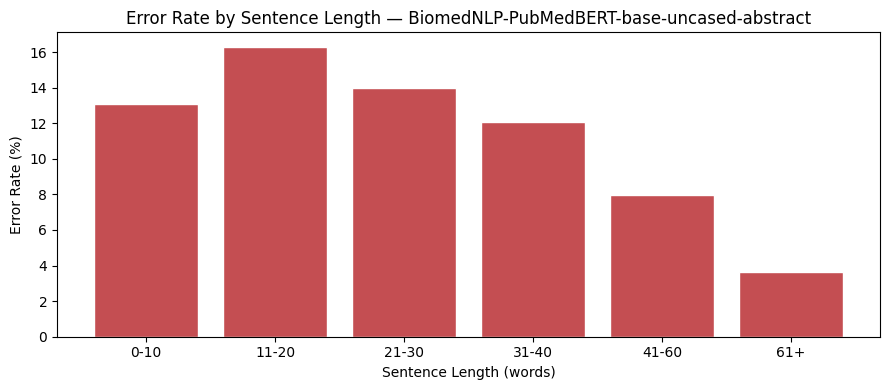

Saved: error_by_length.png


In [27]:
# ── Error rate by sentence length (Transformer) ──────────────────────────────
test_df_err['n_words'] = test_df_err['text'].apply(lambda x: len(x.split()))
test_df_err['error']   = (test_df_err['true'] != test_df_err['pred']).astype(int)

bins = [0, 10, 20, 30, 40, 60, 200]
labels_bins = ['0-10', '11-20', '21-30', '31-40', '41-60', '61+']
test_df_err['length_bin'] = pd.cut(test_df_err['n_words'], bins=bins, labels=labels_bins)

err_by_len = test_df_err.groupby('length_bin')['error'].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(err_by_len['length_bin'].astype(str), err_by_len['error'] * 100, color='#C44E52', edgecolor='white')
ax.set_xlabel('Sentence Length (words)')
ax.set_ylabel('Error Rate (%)')
ax.set_title(f'Error Rate by Sentence Length — {CFG["model_name"].split("/")[-1]}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'error_by_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_by_length.png')

## 6. Qualitative Inspection — Correct Predictions

In [28]:
correct_df = test_df_err[test_df_err['error'] == 0]
print('=== Correctly Classified Examples (2 per class) ===\n')
for label in LABEL_ORDER:
    subset = correct_df[correct_df['true'] == label]
    if len(subset) == 0:
        continue
    print(f'[{label}]')
    for _, row in subset.sample(min(2, len(subset)), random_state=42).iterrows():
        print(f'  ✓ "{row["text"][:150]}"')
    print()

=== Correctly Classified Examples (2 per class) ===

[BACKGROUND]
  ✓ "Financial incentives promote many health behaviors , but effective ways to deliver health incentives remain uncertain ."
  ✓ "Short-term follow-up has shown that duodenum-preserving pancreatic head resections ( DPPHRs ) are superior in outcomes to pancreaticoduodenectomy ."

[OBJECTIVE]
  ✓ "To compare the feasibility and safety between single and bilateral EVD groups ."
  ✓ "The aim of this study was to compare the vacuum assisted wound closure ( VAC ) system ( negative pressure wound therapy ; NPWT ) and alginate wound dr"

[METHODS]
  ✓ "Along with standard of care , @ subjects received , in a double-blinded fashion , ( twice per day ) either arginine , glutamine and - hydroxy -- methy"
  ✓ "Population pharmacokinetic modelling was conducted using NONMEM ."

[RESULTS]
  ✓ "Mild to moderate correlations ( ranging between @ and @ ; P < @ ) were observed between SAP and most OCT parameters in the glaucoma group ."
 

## 7. Final Results Summary

In [30]:
print('='*80)
print('FINAL RESULTS SUMMARY — PubMed RCT 20k')
print('='*80)
print(results_df.to_string())
print('\n--- Perplexity ---')
print(ppl_df.round(4).to_string())
print('\nNote: Random 5-class baseline perplexity = 5.00 | Perfect classifier = 1.00')

print('\n--- All Saved Figures ---')
for fname in ['lstm_training_curves.png', 'lstm_confusion_matrix.png',
              'transf_training_curves.png', 'transf_confusion_matrix.png',
              'model_comparison.png', 'per_class_f1.png', 'error_by_length.png']:
    print(f'  {FIG_DIR / fname}')

FINAL RESULTS SUMMARY — PubMed RCT 20k
                                            Test Loss  Perplexity  Accuracy  Macro F1  Macro Prec.  Macro Rec.  Weighted F1
Model                                                                                                                      
BiLSTM (baseline)                              0.5661      1.7614    0.8395    0.7758       0.7808      0.7749       0.8397
BiomedNLP-PubMedBERT-base-uncased-abstract     0.4481      1.5653    0.8664    0.8085       0.8044      0.8145       0.8677

--- Perplexity ---
                                            Train PPL (final epoch)  Val PPL (best epoch)  Test PPL
Model                                                                                              
BiLSTM                                                       1.1923                1.7088    1.7614
BiomedNLP-PubMedBERT-base-uncased-abstract                   1.3541                1.5248    1.5653

Note: Random 5-class baseline perplexity = 5

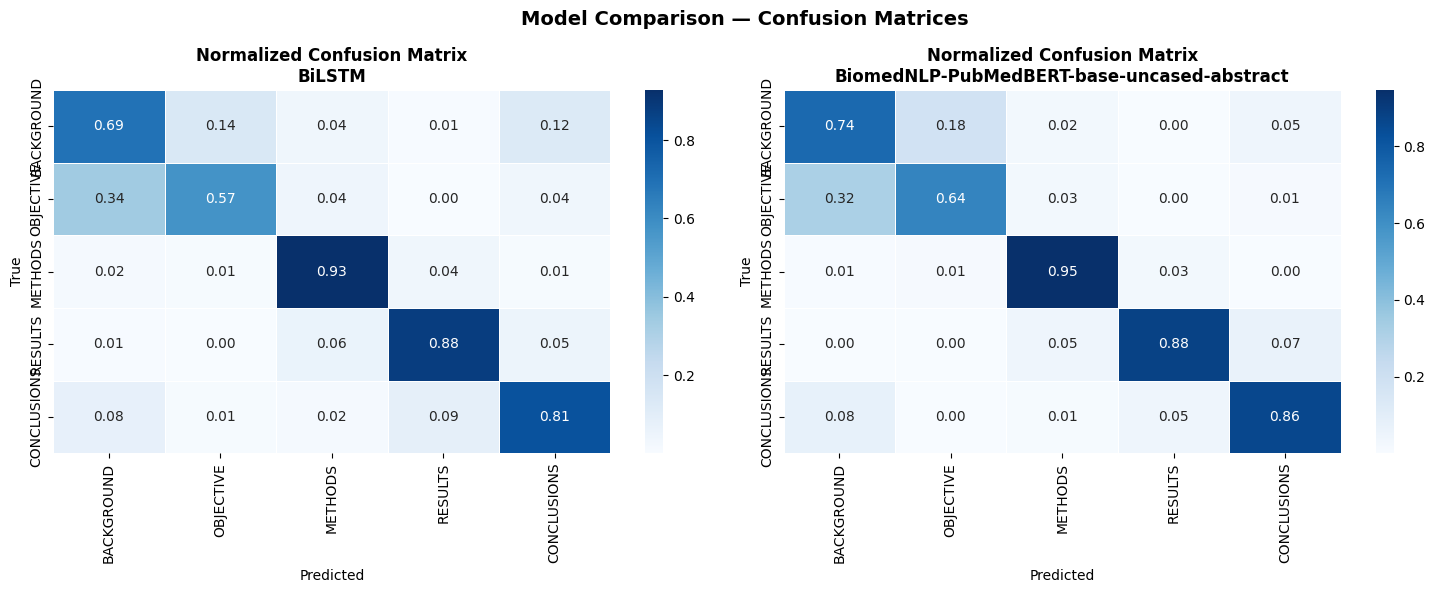

Saved: confusion_matrices_comparison.png


In [31]:
# ── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (preds, true, title) in zip(axes, [
    (lstm_preds,   lstm_true,   'BiLSTM'),
    (transf_preds, transf_true, CFG['model_name'].split('/')[-1])
]):
    cm = confusion_matrix(true, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Normalized Confusion Matrix\n{title}', fontweight='bold')

plt.suptitle('Model Comparison — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_comparison.png')

---
## End of Modeling Notebook

### Summary of outputs:
| File | Description |
|---|---|
| `lstm_best.pt` | Best BiLSTM checkpoint (by val loss) |
| `transf_best.pt` | Best transformer checkpoint (by val loss) |
| `lstm_training_curves.png` | Loss / Accuracy / Perplexity curves — LSTM |
| `transf_training_curves.png` | Loss / Accuracy / Perplexity curves — Transformer |
| `lstm_confusion_matrix.png` | Normalized CM — LSTM |
| `transf_confusion_matrix.png` | Normalized CM — Transformer |
| `confusion_matrices_comparison.png` | Side-by-side CMs |
| `model_comparison.png` | Accuracy / Macro F1 / Weighted F1 bar chart |
| `per_class_f1.png` | Per-class F1 comparison |
| `error_by_length.png` | Transformer error rate by sentence length |

Next steps:
- GitHub README & repository
- Report (4+ pages)
- Presentation/demo